# **Classification**

In [ ]:
# ============================================================================
# COMPLETE CLASSICAL MACHINE LEARNING PIPELINE FOR CLASSIFICATION
# ----------------------------------------------------------------------------
# Works for ANY classification task (binary or multi-class). Default dataset
# below is the sklearn Breast Cancer Wisconsin dataset -- swap it for your own
# CSV in 2 lines (see "LOAD YOUR OWN DATA" section) and everything else works
# unchanged.
#
# Every ML CONCEPT is implemented AND explained (why it's done), not just the
# model list. Covers: EDA, train/test split, leakage-safe preprocessing
# (imputation, scaling, encoding) via Pipelines, class imbalance handling,
# dimensionality reduction (PCA), feature selection, cross-validation,
# hyperparameter tuning, every major non-deep-learning classifier, ensembling
# (bagging/boosting/voting/stacking), the full metric suite, ROC/PR curves,
# overfitting/underfitting + bias-variance diagnostics, feature importance,
# and model persistence.
#
# Paste this whole cell into Google Colab and run it top to bottom.
# ============================================================================

# ----------------------------------------------------------------------------
# 0. INSTALL EXTRA LIBRARIES (Colab has most pre-installed; this is a no-op
#    safety net so the script never breaks because a package is missing)
# WHY: XGBoost/LightGBM/CatBoost are gradient-boosting implementations that
# usually beat plain sklearn GradientBoosting on tabular data, so we include
# them for completeness.
# ----------------------------------------------------------------------------
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "xgboost", "lightgbm", "catboost", "imbalanced-learn"])

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
)
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except ImportError:
    HAS_CAT = False

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



In [ ]:
# ============================================================================
# 1. LOAD YOUR OWN DATA (or use the default breast-cancer demo below)
# WHY: Separating "load data" from "everything else" is what makes this
# script reusable for ANY classification task -- only this block changes.
# ============================================================================
USE_OWN_CSV = True  # <-- set True and fill in the two lines below to use your own data

if USE_OWN_CSV:
    df = pd.read_csv("/content/bank.csv", sep=';') #age,years_workex,...,Job Placement (TARGET_COL) #KAGGLE #age, lifespan, claws, moody ...- Cat-0/Dog-1/
    TARGET_COL = "y"          # <-- name of the label column
    X = df.drop(columns=[TARGET_COL]) #Features #Independent Variables
    y = df[TARGET_COL] #Target Variable
else:
    data = load_breast_cancer()
    X = pd.DataFrame(data.data, columns=data.feature_names)
    y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign

# Encode target if it's text (e.g. "cat"/"dog") -> numbers, because sklearn
# models require numeric labels.
if y.dtype == object:
    y = pd.Series(LabelEncoder().fit_transform(y), name="target")

print("Dataset shape:", X.shape)
print("Class balance:\n", y.value_counts(normalize=True))

Dataset shape: (4521, 16)
Class balance:
 target
0    0.88476
1    0.11524
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no



Missing values per column:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


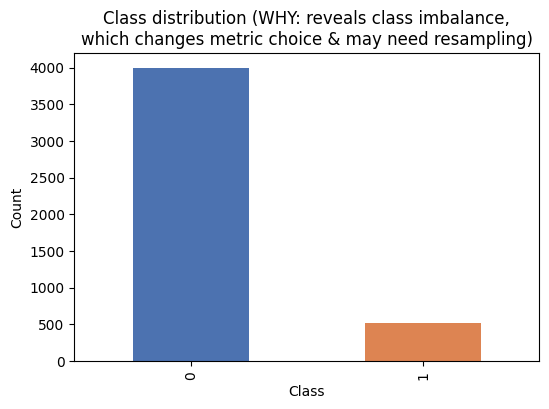

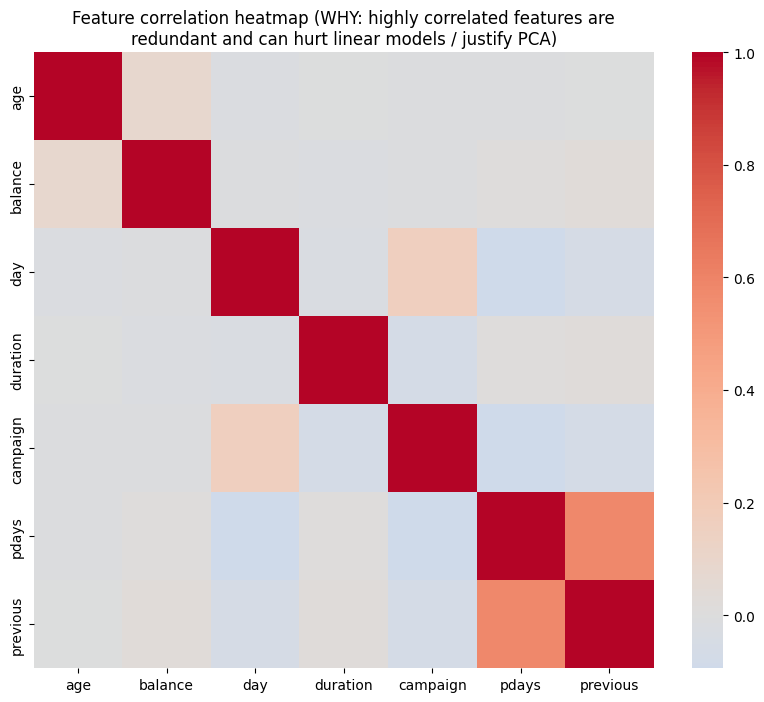

In [ ]:
# ============================================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# WHY: You must understand the data BEFORE modeling -- missing values, scale
# differences between features, class imbalance, and correlated/redundant #years of work, 2*years of work ex

# 1000 People came for loan
# 990 People pay loan on time (no-default)-99%; 10 defaulted (1%)
# Rule/ML Model to predict Loan credit (Y/N) decision Automated-

# Features all directly affect which preprocessing steps and models make sense.
# Skipping EDA is the #1 cause of silently broken pipelines.
# ============================================================================

# Define numeric and categorical columns for EDA
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("\nMissing values per column:\n", X.isnull().sum())

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind="bar", color=["#4c72b0", "#dd8452"])
plt.title("Class distribution (WHY: reveals class imbalance,\nwhich changes metric choice & may need resampling)")
plt.xlabel("Class"); plt.ylabel("Count"); plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(X[numeric_cols].corr(), cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap (WHY: highly correlated features are\nredundant and can hurt linear models / justify PCA)")
plt.show()

In [ ]:
# ============================================================================
# 3. TRAIN / TEST SPLIT
# WHY: We evaluate on data the model never saw during training to get an
# honest estimate of real-world performance. STRATIFY keeps the same class
# ratio in both splits -- critical for imbalanced datasets, otherwise the
# test set could accidentally end up with almost no minority-class examples.
# ============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")



Train size: (3616, 16), Test size: (905, 16)


In [ ]:

# ============================================================================
# 4. PREPROCESSING PIPELINE (imputation + scaling + encoding)
# WHY a Pipeline (not manual fit_transform on the whole dataset): fitting a
# scaler/imputer on the FULL dataset before splitting leaks test-set
# information into training (data leakage), inflating your reported
# accuracy. A Pipeline fits preprocessing ONLY on training folds each time,
# so cross-validation and the final test score stay honest.
#
# - SimpleImputer: fills missing values (mean for numeric) -- most sklearn
#   models cannot handle NaNs at all.
# - StandardScaler: rescales features to mean 0 / std 1. WHY: distance-based
#   models (KNN, SVM) and gradient-based models (Logistic Regression, SGD)
#   are dominated by whichever feature has the largest raw magnitude unless
#   all features are on the same scale. Tree-based models don't need this,
#   but it never hurts them, so we apply it uniformly for simplicity.
# - OneHotEncoder (for categorical columns, if any): converts categories
#   into binary columns because models need numeric input, and integer-
#   encoding categories implies a false ordering.
# ============================================================================
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

from sklearn.preprocessing import OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])

In [ ]:

# ============================================================================
# 5. CLASS IMBALANCE HANDLING (SMOTE)
# WHY: If one class is rare, models can get high accuracy just by always
# predicting the majority class. SMOTE synthesizes new minority-class
# samples (by interpolating between real ones) ONLY on the training data,
# so the model actually learns the minority class's decision boundary
# instead of ignoring it. We check the imbalance ratio and only apply it
# when it's meaningfully skewed (e.g. worse than 65/35).
# ============================================================================
imbalance_ratio = y_train.value_counts(normalize=True).min()
USE_SMOTE = HAS_IMBLEARN and imbalance_ratio < 0.35
print(f"\nMinority class fraction in train: {imbalance_ratio:.3f} -> using SMOTE: {USE_SMOTE}")

def make_pipeline(model):
    """Builds preprocessing (+ optional SMOTE) + model as one leakage-safe unit."""
    if USE_SMOTE:
        return ImbPipeline(steps=[
            ("preprocess", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", model),
        ])
    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model),
    ])


Minority class fraction in train: 0.115 -> using SMOTE: True


In [ ]:


# ============================================================================
# 6. DIMENSIONALITY REDUCTION & FEATURE SELECTION (demonstrated, optional)
# WHY PCA: When features are highly correlated / numerous, PCA compresses
# them into a smaller set of uncorrelated "components" that capture most of
# the variance, which speeds up training and can reduce overfitting/noise.
# WHY SelectKBest: keeps only the features most statistically associated
# with the target (ANOVA F-test), which fights the "curse of dimensionality"
# -- with too many irrelevant features, distance-based models like KNN and
# even linear models become noisier and slower.
# These are shown standalone here; in production you'd insert them as a
# pipeline step the same way SMOTE was inserted above.
# ============================================================================
X_train_num = X_train[numeric_cols].fillna(X_train[numeric_cols].mean())
X_train_scaled_demo = StandardScaler().fit_transform(X_train_num)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)  # keep 95% of variance
X_pca_demo = pca.fit_transform(X_train_scaled_demo)
print(f"\nPCA: {X_train_num.shape[1]} original features -> {X_pca_demo.shape[1]} components explain 95% variance")

selector = SelectKBest(score_func=f_classif, k=min(10, X_train_num.shape[1]))
selector.fit(X_train_num, y_train)
top_features = X_train_num.columns[selector.get_support()].tolist()
print("Top features by ANOVA F-test:", top_features)


PCA: 7 original features -> 7 components explain 95% variance
Top features by ANOVA F-test: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:


# ============================================================================
# 7. CROSS-VALIDATION SETUP
# WHY: A single train/test split gives a noisy performance estimate --  you
# might get a lucky or unlucky split. K-Fold cross-validation trains/evaluates
# the model K times on different splits of the TRAINING data and averages the
# results, giving a much more reliable estimate and a sense of variance.
# StratifiedKFold keeps class ratios consistent in every fold (same reason as
# stratified train/test split above).
# ============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [ ]:
# ============================================================================
# 8. DEFINE EVERY CLASSICAL (NON-DEEP-LEARNING) MODEL
# Each model represents a different learning paradigm; short WHY / when to
# use is given as a comment. You will have to search for each model to learn how the model works.
# ============================================================================
models = {
    # --- Linear models ---
    # Learns a linear decision boundary + sigmoid -> probability. Fast,
    # interpretable (coefficients = feature effect), strong baseline.
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),

    # Same idea as Logistic Regression but optimizes squared error with L2
    # penalty and no probability output -- very fast on large data.
    "Ridge Classifier": RidgeClassifier(random_state=RANDOM_STATE),

    # Trains linear/logistic-style models via mini-batch gradient descent,
    # which scales to very large datasets that don't fit in memory at once.
    "SGD Classifier": SGDClassifier(loss="log_loss", random_state=RANDOM_STATE),

    # The original linear neural unit (single layer, step function). Included
    # for completeness as the simplest possible linear classifier; only
    # works well when classes are linearly separable.
    "Perceptron": Perceptron(random_state=RANDOM_STATE),

    # --- Distance-based ---
    # Classifies a point by majority vote of its K nearest neighbors in
    # feature space. Non-parametric (no assumptions about data shape), but
    # sensitive to feature scale and the curse of dimensionality -- this is
    # WHY we scaled features and demonstrated feature selection above.
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),

    # --- Margin-based ---
    # Finds the hyperplane that maximizes the margin between classes. The
    # RBF "kernel trick" implicitly maps data to higher dimensions to
    # separate classes that aren't linearly separable in the original space.
    "SVM (RBF kernel)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "SVM (Linear kernel)": SVC(kernel="linear", probability=True, random_state=RANDOM_STATE),
    "Linear SVC": LinearSVC(max_iter=5000, random_state=RANDOM_STATE),

    # --- Probabilistic ---
    # Applies Bayes' theorem assuming features are conditionally independent
    # given the class (a strong, often-wrong, but surprisingly effective
    # assumption). Extremely fast, great baseline, needs little data.
    "Gaussian Naive Bayes": GaussianNB(),
    "Bernoulli Naive Bayes": BernoulliNB(),

    # Both assume each class's features follow a Gaussian distribution.
    # LDA assumes classes share one covariance matrix (linear boundary);
    # QDA lets each class have its own (quadratic/curved boundary).
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    # reg_param shrinks each class's covariance estimate toward a shared
    # diagonal one. WHY: QDA estimates a separate covariance matrix per
    # class; with many correlated features and limited samples per class,
    # that matrix can become singular (not invertible) -- regularization
    # fixes this the same way ridge regularization stabilizes linear models.
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(reg_param=0.1),

    # --- Tree-based (single tree) ---
    # Splits data recursively on the feature/threshold that best separates
    # classes (e.g. Gini impurity). Highly interpretable but prone to
    # overfitting on its own -- hence the ensembles below.
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),

    # --- Bagging ensembles (reduce VARIANCE) ---
    # Trains many trees on bootstrapped (random-with-replacement) samples of
    # the data and averages their votes. WHY: individual trees overfit
    # (high variance); averaging many de-correlated trees cancels out their
    # individual noise, giving a much more stable model (bias-variance
    # tradeoff: bagging mainly reduces variance).
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),

    # Like Random Forest but splits are chosen at random thresholds too
    # (Extremely Randomized Trees), trading a bit more bias for even lower
    # variance and faster training.
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_STATE),

    # Generic bagging wrapper around any base estimator (here, decision
    # trees) -- shown to illustrate that bagging is a general technique, not
    # unique to Random Forest.
    "Bagging (Trees)": BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=200, random_state=RANDOM_STATE),

    # --- Boosting ensembles (reduce BIAS) ---
    # Trains models sequentially, where each new model focuses on the
    # examples the previous ones got wrong (reweighted samples). WHY: unlike
    # bagging, boosting mainly reduces bias -- it turns many "weak learners"
    # (shallow trees) into a strong one by iteratively correcting mistakes.
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),

    # Boosting where each new tree fits the RESIDUAL ERROR (gradient of the
    # loss) of the ensemble so far, rather than reweighting samples --
    # generally more accurate than AdaBoost on tabular data.
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

if HAS_XGB:
    # Gradient boosting with regularization + optimized tree-building --
    # usually the strongest off-the-shelf model for structured/tabular data.
    models["XGBoost"] = XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE)

if HAS_LGBM:
    # Gradient boosting that grows trees leaf-wise (vs level-wise) using
    # histogram binning -- much faster on large/high-dimensional data.
    models["LightGBM"] = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

if HAS_CAT:
    # Gradient boosting with built-in, statistically principled handling of
    # categorical features (no manual one-hot encoding needed for them).
    models["CatBoost"] = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)

# --- Voting ensemble ---
# Combines several DIFFERENT model types and averages their predicted
# probabilities ("soft" voting). WHY: models with different biases (linear,
# distance-based, tree-based) make different mistakes; averaging them out
# often beats any single model, especially when no one model dominates.
voting_estimators = [
    ("lr", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier(n_neighbors=5)),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
]
models["Voting Ensemble"] = VotingClassifier(estimators=voting_estimators, voting="soft")

# --- Stacking ensemble ---
# Trains several "base" models, then trains a "meta-model" (here, Logistic
# Regression) on THEIR predictions to learn the best way to combine them --
# more flexible than fixed averaging in Voting, at the cost of more
# complexity and a higher risk of overfitting on small datasets.
stacking_estimators = [
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("svc", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    ("nb", GaussianNB()),
]
models["Stacking Ensemble"] = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    cv=5,)



In [ ]:

# ============================================================================
# 9. TRAIN + CROSS-VALIDATE + EVALUATE EVERY MODEL
# WHY report BOTH cross-val score and held-out test score: CV tells you how
# stable/reliable the model is across different data slices; the held-out
# test score is your final, unbiased estimate of real-world performance.
# ============================================================================
results = []

for name, model in models.items():
    pipe = make_pipeline(model)

    # Cross-validation on the TRAIN set only (test set stays untouched until
    # final evaluation, so it never influences model choice = no leakage).
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None and len(np.unique(y)) == 2 else np.nan

    results.append({
        "Model": name,
        "CV Accuracy (mean)": cv_scores.mean(),
        "CV Accuracy (std)": cv_scores.std(),
        "Test Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc,
    })

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
print("\n=== MODEL COMPARISON (sorted by Test Accuracy) ===")
print(results_df.to_string(index=False))


KeyboardInterrupt: 

In [ ]:

# ============================================================================
# 10. METRIC EXPLANATIONS (why we look at more than accuracy)
# - Accuracy: overall % correct. Misleading on imbalanced data (a model that
#   always predicts the majority class can still score high).
# - Precision: of predicted positives, how many were actually positive.
#   Matters when false positives are costly (e.g. flagging a healthy patient
#   as sick).
# - Recall: of actual positives, how many did we catch. Matters when false
#   negatives are costly (e.g. missing a malignant tumor).
# - F1: harmonic mean of precision & recall -- a single number balancing
#   both, useful when you care about both errors.
# - ROC-AUC: probability the model ranks a random positive higher than a
#   random negative, across ALL classification thresholds -- summarizes
#   discriminative power independent of the chosen decision threshold.
# ============================================================================

best_model_name = results_df.iloc[0]["Model"]
best_pipe = make_pipeline(models[best_model_name]).fit(X_train, y_train)
y_pred_best = best_pipe.predict(X_test)

print(f"\n=== DETAILED REPORT FOR BEST MODEL: {best_model_name} ===")
print(classification_report(y_test, y_pred_best))

# Confusion matrix: rows = actual class, columns = predicted class.
# WHY: breaks accuracy down into True/False Positives/Negatives so you can
# see EXACTLY what kind of mistakes the model makes, not just how many.
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

# ROC curve: True Positive Rate vs False Positive Rate at every threshold.
# WHY: shows the full tradeoff between catching positives and raising false
# alarms, letting you pick a threshold matching your real-world cost of
# each error type (not just accuracy at the default 0.5 cutoff).
if hasattr(best_pipe, "predict_proba") and len(np.unique(y)) == 2:
    y_proba_best = best_pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_best)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba_best):.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {best_model_name}"); plt.legend(); plt.show()

    # Precision-Recall curve: more informative than ROC when classes are
    # imbalanced, since it focuses on the positive (often minority) class.
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba_best)
    plt.figure(figsize=(5, 4))
    plt.plot(rec_curve, prec_curve)
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {best_model_name}"); plt.show()

In [ ]:


# ============================================================================
# 11. MODEL COMPARISON PLOT
# WHY: visualizing all models side by side (with error bars from CV std)
# makes it obvious which models are meaningfully better vs. within noise of
# each other -- a bar chart of a single accuracy number can be misleading.
# ============================================================================
plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["Test Accuracy"], xerr=results_df["CV Accuracy (std)"])
plt.xlabel("Test Accuracy"); plt.title("Model Comparison (error bars = CV std-dev)")
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()


In [ ]:

# ============================================================================
# 12. HYPERPARAMETER TUNING (GridSearchCV / RandomizedSearchCV)
# WHY: default hyperparameters are rarely optimal. GridSearchCV exhaustively
# tries every combination in a grid (thorough but slow); RandomizedSearchCV
# samples random combinations (faster, scales to bigger search spaces). Both
# use cross-validation internally so the "best" params aren't just overfit
# to one split. We tune Random Forest and SVM here as examples -- the same
# pattern applies to any model above.
# ============================================================================
rf_param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
}
rf_grid = GridSearchCV(
    make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
    param_grid=rf_param_grid, cv=cv, scoring="accuracy", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("\nBest Random Forest params:", rf_grid.best_params_)
print("Best Random Forest CV accuracy:", rf_grid.best_score_)
print("Random Forest test accuracy after tuning:", accuracy_score(y_test, rf_grid.predict(X_test)))

svm_param_dist = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "model__kernel": ["rbf", "linear"],
}
svm_random = RandomizedSearchCV(
    make_pipeline(SVC(probability=True, random_state=RANDOM_STATE)),
    param_distributions=svm_param_dist, n_iter=15, cv=cv,
    scoring="accuracy", random_state=RANDOM_STATE, n_jobs=-1
)
svm_random.fit(X_train, y_train)
print("\nBest SVM params:", svm_random.best_params_)
print("Best SVM CV accuracy:", svm_random.best_score_)
print("SVM test accuracy after tuning:", accuracy_score(y_test, svm_random.predict(X_test)))

In [ ]:


# ============================================================================
# 13. BIAS-VARIANCE / OVERFITTING-UNDERFITTING DIAGNOSTIC (Learning Curve)
# WHY: comparing training-set score vs cross-validation score as training
# size grows tells you WHICH problem you have:
#  - both scores low & close together      -> UNDERFITTING (high bias):
#    model too simple / needs more features or a more powerful model.
#  - training score high, CV score much lower -> OVERFITTING (high variance):
#    model memorized training data; needs regularization, more data, or a
#    simpler model.
#  - both scores high & close together      -> good fit.
# ============================================================================
train_sizes, train_scores, val_scores = learning_curve(
    make_pipeline(RandomForestClassifier(random_state=RANDOM_STATE)),
    X_train, y_train, cv=cv, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Cross-validation score")
plt.xlabel("Training set size"); plt.ylabel("Accuracy")
plt.title("Learning Curve (Random Forest) - diagnoses over/underfitting")
plt.legend(); plt.show()


In [ ]:

# ============================================================================
# 14. FEATURE IMPORTANCE / INTERPRETABILITY
# WHY: knowing WHICH features drive predictions builds trust in the model,
# helps catch data leakage (a suspiciously dominant feature), and guides
# future feature engineering. Tree models expose importance directly;
# linear models expose it via coefficient magnitude (on scaled features, so
# magnitudes are comparable).
# ============================================================================
rf_best = rf_grid.best_estimator_
importances = rf_best.named_steps["model"].feature_importances_
if len(importances) == len(numeric_cols):  # no categorical columns were one-hot expanded
    imp_df = pd.DataFrame({"feature": numeric_cols, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature")
    plt.title("Top 15 Feature Importances (Random Forest)")
    plt.tight_layout(); plt.show()

lr_pipe = make_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)).fit(X_train, y_train)
lr_coefs = lr_pipe.named_steps["model"].coef_[0]
if len(lr_coefs) == len(numeric_cols):
    coef_df = pd.DataFrame({"feature": numeric_cols, "coefficient": lr_coefs})
    coef_df = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(data=coef_df, x="coefficient", y="feature")
    plt.title("Top 15 Logistic Regression Coefficients (scaled features)")
    plt.tight_layout(); plt.show()

In [ ]:


# ============================================================================
# 15. REGULARIZATION DEMO (L1 vs L2 in Logistic Regression)
# WHY: regularization penalizes large coefficients to fight overfitting.
# L2 (ridge) shrinks all coefficients smoothly; L1 (lasso) can shrink some
# coefficients to EXACTLY zero, performing automatic feature selection.
# ============================================================================
for penalty, solver in [("l2", "lbfgs"), ("l1", "liblinear")]:
    pipe = make_pipeline(LogisticRegression(penalty=penalty, solver=solver, max_iter=5000, random_state=RANDOM_STATE))
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    n_zero = np.sum(pipe.named_steps["model"].coef_[0] == 0)
    print(f"Logistic Regression ({penalty} penalty): test accuracy={acc:.4f}, zeroed-out coefficients={n_zero}")

In [ ]:


# ============================================================================
# 16. SAVE THE BEST MODEL (persistence)
# WHY: you train once, then reuse the fitted pipeline (preprocessing +
# model together) to predict on new data later, without retraining, and
# without redoing preprocessing by hand -- avoids train/serve skew.
# ============================================================================
joblib.dump(best_pipe, "best_model_pipeline.joblib")
print(f"\nSaved best model ({best_model_name}) to best_model_pipeline.joblib")

# Example of loading it back and predicting on new/unseen rows:
loaded_pipe = joblib.load("best_model_pipeline.joblib")
sample_preds = loaded_pipe.predict(X_test.iloc[:5])
print("Sample predictions from reloaded model:", sample_preds)

print("\n=== DONE ===")
print(f"Best model: {best_model_name} | Test accuracy: {results_df.iloc[0]['Test Accuracy']:.4f}")

# 17. ADDITIONAL MACHINE LEARNING CONCEPTS

In [ ]:
# --- Setup for Additional ML Concepts ---
# Re-import necessary variables and functions for the new sections
# These were defined in previous cells but might not be in the current execution scope
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

# Re-evaluate imblearn status and import if available
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False

# Global variables from previous cells
RANDOM_STATE = 42

# Ensure X, y, X_train, X_test, y_train, y_test are defined (from cell Q_35HYgRy6bw and nqr6AJ8a0iJ1)
# Assuming df is available from Q_35HYgRy6bw execution, re-create it to ensure consistency
df = pd.read_csv("/content/bank.csv", sep=';')
TARGET_COL = "y"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]
if y.dtype == object:
    y = pd.Series(LabelEncoder().fit_transform(y), name="target")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Ensure numeric_cols and categorical_cols are defined (from cell S2RXaL8o0tYj)
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# Ensure preprocessor is defined (from cell S2RXaL8o0tYj)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols),
])
# Fit preprocessor here to make it ready for use by subsequent cells
preprocessor.fit(X_train)

# Ensure make_pipeline is defined (from cell Ce0zFpLv1q_Q)
imbalance_ratio = y_train.value_counts(normalize=True).min()
USE_SMOTE = HAS_IMBLEARN and imbalance_ratio < 0.35

def make_pipeline(model):
    """Builds preprocessing (+ optional SMOTE) + model as one leakage-safe unit."""
    if USE_SMOTE:
        return ImbPipeline(steps=[
            ("preprocess", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", model),
        ])
    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model),
    ])

print("Setup for additional ML concepts complete.")


Setup for additional ML concepts complete.


## 17.1 Advanced Model Interpretability (LIME, SHAP)

**WHY:** Understanding *why* a model makes a particular prediction is crucial for building trust, debugging, identifying bias, and complying with regulations. Simple feature importances can be global but don't explain individual predictions. More advanced methods like LIME (Local Interpretable Model-agnostic Explanations) and SHAP (SHapley Additive exPlanations) provide deeper insights:

*   **LIME:** Explains individual predictions by locally approximating the model around the prediction with an interpretable model (e.g., a linear model).
*   **SHAP:** Provides game-theoretic optimal Shapley values, which quantify how much each feature contributes to an individual prediction, pushing it higher or lower from the base value. SHAP can also provide global interpretations by aggregating individual SHAP values.

  0%|          | 0/10 [00:00<?, ?it/s]


SHAP Force plots for each of the first 10 test instances (Logistic Regression):



Force plot for instance 1:



Force plot for instance 2:



Force plot for instance 3:



Force plot for instance 4:



Force plot for instance 5:



Force plot for instance 6:



Force plot for instance 7:



Force plot for instance 8:



Force plot for instance 9:



Force plot for instance 10:



SHAP Summary plot (Logistic Regression):


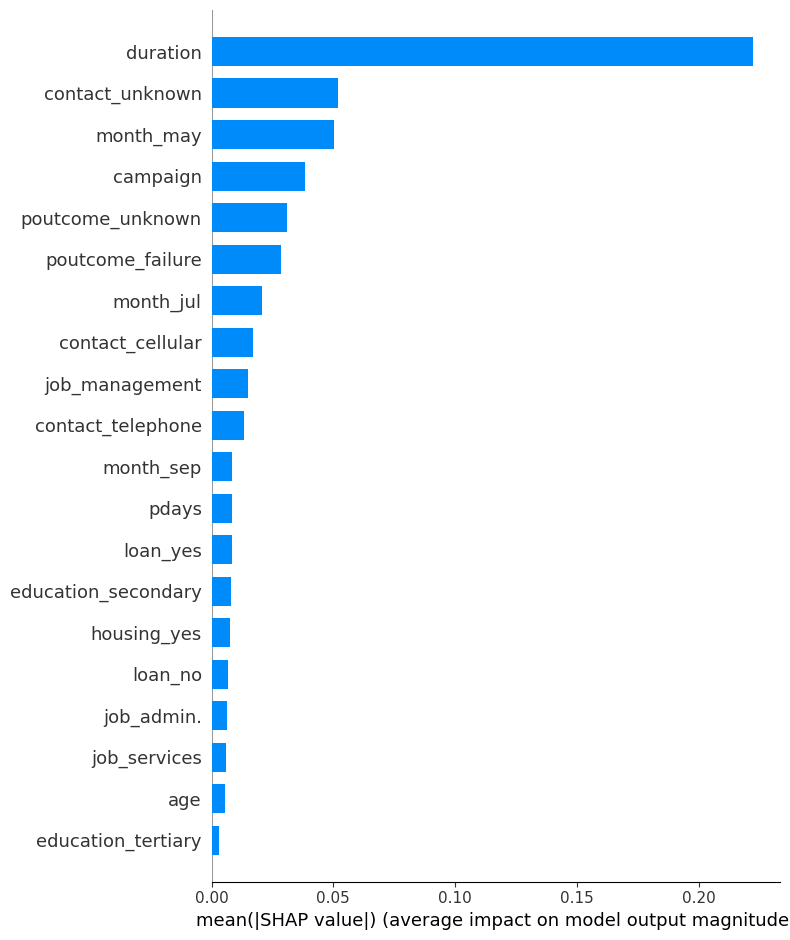

In [ ]:
# Install SHAP if not already installed
try:
    import shap
except ImportError:
    %pip install -qq shap
    import shap

# Using the best pipeline from earlier
# Note: SHAP can be computationally intensive for complex models or large datasets.
# We'll use a subset of the test data for demonstration.

# sampler = shap.sample(X_test, 100) # This line is not used in the current SHAP explanation

# For pipeline models, we need to explain the model component,
# but the explainer needs to know about the preprocessor.
# A common approach for pipelines is to use a custom explainer or explain the final model
# on preprocessed data. For simplicity here, we'll try to explain the whole pipeline.
# Note: Direct SHAP explanation of a complex pipeline can be tricky.
# Often, you'd explain the final estimator on the preprocessed data.

# Let's create a simpler explainer for a Logistic Regression for demonstration
# since the `best_pipe` might be a complex ensemble.
# For a more robust pipeline explanation, consider `shap.Explainer` with a custom masker.

# For demonstration, let's use a simpler model (e.g., Logistic Regression)
# from the pipeline if it's interpretable, or explain the overall pipeline's predictions.

# To get SHAP values, we need the raw preprocessed data for the explainer.
# Let's extract the preprocessed test data for a Logistic Regression example.

lr_pipe = make_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
lr_pipe.fit(X_train, y_train)

# Apply preprocessing to the test data for the explainer
X_test_processed = lr_pipe.named_steps['preprocess'].transform(X_test)

# Get feature names after one-hot encoding
feature_names = numeric_cols + list(lr_pipe.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols))

# Create a background dataset for the explainer (e.g., a sample of the training data)
X_train_processed_sample = lr_pipe.named_steps['preprocess'].transform(X_train.sample(100, random_state=RANDOM_STATE))

# Define the prediction function to explain (probability of positive class)
predict_fn = lambda x: lr_pipe.named_steps['model'].predict_proba(x)[:, 1]
explainer = shap.KernelExplainer(predict_fn, X_train_processed_sample)

# Define the subset of data for which SHAP values will be calculated
X_test_subset = X_test_processed[:10]
shap_values = explainer.shap_values(X_test_subset) # Explain first 10 instances

# Visualize the explanation for a single prediction
print("\nSHAP Force plots for each of the first 10 test instances (Logistic Regression):")
shap.initjs()
for i in range(len(X_test_subset)):
    print(f"\nForce plot for instance {i+1}:")
    display(shap.force_plot(explainer.expected_value, shap_values[i,:], X_test_subset[i,:], feature_names=feature_names))

# Visualize overall feature importance
print("\nSHAP Summary plot (Logistic Regression):")
# Now shap_values is a single array (n_samples, n_features)
shap.summary_plot(shap_values, X_test_subset, feature_names=feature_names, plot_type="bar")

## 17.2 Semi-supervised Learning

**WHY:** In many real-world scenarios, obtaining labeled data is expensive and time-consuming, while unlabeled data is abundant. Semi-supervised learning methods leverage both labeled and unlabeled data during training to improve model performance, especially when labels are scarce. This can lead to more robust models than purely supervised learning with limited labels or purely unsupervised learning.

In [ ]:
from sklearn.semi_supervised import LabelSpreading

# For demonstration, let's create a scenario with partially labeled data.
# We'll take a small fraction of y_train as labeled, and the rest as unlabeled (-1).

# Make sure X_train is preprocessed. For simplicity, let's use numeric features only.
# In a real scenario, the preprocessor would be applied.

X_train_processed_numeric = preprocessor.named_transformers_['num'].fit_transform(X_train[numeric_cols])

# Create partially labeled y_train
partially_labeled_y = np.copy(y_train)
# Randomly set 90% of labels to -1 (unlabeled)
random_unlabeled_indices = np.random.choice(
    len(y_train), size=int(0.9 * len(y_train)), replace=False)
partially_labeled_y[random_unlabeled_indices] = -1

print(f"Original labeled data points: {len(y_train)}")
print(f"Labeled data points for semi-supervised learning: {np.sum(partially_labeled_y != -1)}")
print(f"Unlabeled data points for semi-supervised learning: {np.sum(partially_labeled_y == -1)}")

# Apply LabelSpreading
label_spreading_model = LabelSpreading(kernel='knn', gamma=0.25, alpha=0.5, max_iter=20, n_neighbors=7)

# Train the model on the partially labeled data
# Note: LabelSpreading is designed for dense data, converting sparse matrix if necessary.
if hasattr(X_train_processed_numeric, 'toarray'):
    label_spreading_model.fit(X_train_processed_numeric.toarray(), partially_labeled_y)
else:
    label_spreading_model.fit(X_train_processed_numeric, partially_labeled_y)

# Get the inferred labels (including the originally unlabeled ones)
inferred_labels = label_spreading_model.transduction_

# Evaluate accuracy on the originally unlabeled points
# Note: This is an illustrative example; full evaluation requires careful setup.
# Use .iloc for positional indexing on the y_train Series
original_unlabeled_true_labels = y_train.iloc[random_unlabeled_indices]
inferred_unlabeled_predictions = inferred_labels[random_unlabeled_indices]

# Filter out -1 predictions from inferred_unlabeled_predictions if any remain (shouldn't post-fit)
valid_inferred_mask = inferred_unlabeled_predictions != -1
accuracy_on_unlabeled = accuracy_score(original_unlabeled_true_labels[valid_inferred_mask],
                                       inferred_unlabeled_predictions[valid_inferred_mask])

print(f"\nAccuracy on originally unlabeled points (inferred by LabelSpreading): {accuracy_on_unlabeled:.4f}")

Original labeled data points: 3616
Labeled data points for semi-supervised learning: 39
Unlabeled data points for semi-supervised learning: 3577

Accuracy on originally unlabeled points (inferred by LabelSpreading): 0.0000


## 17.3 Cost-Sensitive Learning

**WHY:** Not all misclassifications are equally costly. In many real-world problems (e.g., medical diagnosis, fraud detection), a False Negative (missing a positive case) might be far more damaging than a False Positive (incorrectly flagging a negative case), or vice-versa. Cost-sensitive learning aims to build models that minimize the total cost of errors, rather than just the number of errors (accuracy).

Common approaches include:
*   **Class Weighting:** Assigning different weights to classes during model training, making the model penalize errors on the more 'costly' class more heavily.
*   **Threshold Adjustment:** After training, adjusting the decision threshold for probability predictions to favor one class over another based on a predefined cost matrix.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, confusion_matrix

# Demonstrate class weighting with Logistic Regression
# The 'balanced' option automatically assigns weights inversely proportional
# to class frequencies in the input data.

print("\n--- Logistic Regression with balanced class weights ---")
lr_weighted_pipe = make_pipeline(LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
lr_weighted_pipe.fit(X_train, y_train)
y_pred_weighted = lr_weighted_pipe.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_weighted, average='weighted', zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_weighted, average='weighted', zero_division=0):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_weighted))

# Demonstrate threshold adjustment (e.g., for higher recall, potentially at the cost of precision)
# Let's assume False Negatives are 10x more costly than False Positives.
# Cost Matrix: [[Cost_TN, Cost_FP], [Cost_FN, Cost_TP]]
# For binary classification, typically you want to minimize C_FP * FP + C_FN * FN
# A simple way to adjust threshold is to pick one that maximizes a desired metric

print("\n--- Threshold Adjustment for higher Recall (using default LR) ---")
default_lr_pipe = make_pipeline(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
default_lr_pipe.fit(X_train, y_train)
y_proba_default = default_lr_pipe.predict_proba(X_test)[:, 1]

# Calculate precision and recall for various thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_default)

# Find the threshold that yields a recall of at least 0.8 (example target)
target_recall = 0.8
threshold_for_target_recall = 0.5 # Default
for i, r in enumerate(recalls):
    if r >= target_recall:
        threshold_for_target_recall = thresholds[i]
        break

y_pred_adjusted_threshold = (y_proba_default >= threshold_for_target_recall).astype(int)

print(f"Adjusted threshold to achieve Recall >= {target_recall}: {threshold_for_target_recall:.4f}")
print(f"Accuracy (adjusted threshold): {accuracy_score(y_test, y_pred_adjusted_threshold):.4f}")
print(f"Precision (adjusted threshold): {precision_score(y_test, y_pred_adjusted_threshold, average='weighted', zero_division=0):.4f}")
print(f"Recall (adjusted threshold): {recall_score(y_test, y_pred_adjusted_threshold, average='weighted', zero_division=0):.4f}")
print("Confusion Matrix (adjusted threshold):\n", confusion_matrix(y_test, y_pred_adjusted_threshold))



--- Logistic Regression with balanced class weights ---
Accuracy: 0.2862
Precision: 0.8344
Recall: 0.2862
Confusion Matrix:
 [[  0   0   0]
 [533 252  16]
 [ 70  27   7]]

--- Threshold Adjustment for higher Recall (using default LR) ---
Adjusted threshold to achieve Recall >= 0.8: 0.0000
Accuracy (adjusted threshold): 0.1149
Precision (adjusted threshold): 0.0132
Recall (adjusted threshold): 0.1149
Confusion Matrix (adjusted threshold):
 [[  0 801]
 [  0 104]]


## 17.4 Multi-label Classification

**WHY:** Traditional classification assumes each instance belongs to exactly one class. However, in many domains, an instance can simultaneously belong to multiple classes (e.g., an image can contain both a 'cat' and a 'dog'; a document can be tagged with 'politics' and 'economy'). Multi-label classification models are designed to handle these scenarios by predicting a set of target labels for each input.

In [ ]:
from sklearn.datasets import make_multilabel_classification
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import jaccard_score

# Create a synthetic multi-label dataset for demonstration
X_multi, y_multi = make_multilabel_classification(
    n_samples=300, n_features=20, n_classes=3, n_labels=2,
    length=50, allow_unlabeled=False, random_state=RANDOM_STATE
)

print(f"Synthetic Multi-label X shape: {X_multi.shape}")
print(f"Synthetic Multi-label y shape: {y_multi.shape}")
print("Example of a multi-label target for one instance:", y_multi[0])

# Split the synthetic data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.3, random_state=RANDOM_STATE
)

# Use MultiOutputClassifier with a base estimator (e.g., Logistic Regression)
# MultiOutputClassifier trains one classifier per target label.
base_classifier = LogisticRegression(max_iter=1000, solver='liblinear', random_state=RANDOM_STATE)
multi_label_model = MultiOutputClassifier(base_classifier, n_jobs=-1)

# Fit the model
multi_label_model.fit(X_train_multi, y_train_multi)

# Make predictions
y_pred_multi = multi_label_model.predict(X_test_multi)

print("\nExample true labels for first 5 test instances:\n", y_test_multi[:5])
print("Example predicted labels for first 5 test instances:\n", y_pred_multi[:5])

# Evaluate performance using Jaccard similarity score
# Jaccard score (or Jaccard index) is a common metric for multi-label classification.
# It measures the similarity between the predicted set of labels and the true set of labels.
# (Intersection of sets / Union of sets)

jaccard_micro = jaccard_score(y_test_multi, y_pred_multi, average='micro')
jaccard_macro = jaccard_score(y_test_multi, y_pred_multi, average='macro')

print(f"\nMulti-label Jaccard Score (Micro): {jaccard_micro:.4f}")
print(f"Multi-label Jaccard Score (Macro): {jaccard_macro:.4f}")


Synthetic Multi-label X shape: (300, 20)
Synthetic Multi-label y shape: (300, 3)
Example of a multi-label target for one instance: [0 1 0]

Example true labels for first 5 test instances:
 [[0 1 0]
 [0 0 1]
 [0 0 1]
 [1 1 0]
 [0 1 1]]
Example predicted labels for first 5 test instances:
 [[0 1 0]
 [0 0 1]
 [0 0 1]
 [1 1 0]
 [0 1 1]]

Multi-label Jaccard Score (Micro): 0.8266
Multi-label Jaccard Score (Macro): 0.8099


## 17.5 Model Calibration

**WHY:** A model's predicted probabilities (e.g., from `predict_proba`) are not always a true reflection of confidence. A model might predict a probability of 0.8 for 100 samples, but only 60 of them turn out to be positive. In such a case, the model is poorly calibrated. Calibration techniques adjust the model's output probabilities so that they align better with the actual likelihood of an event, which is essential for applications requiring reliable probability estimates (e.g., risk assessment, decision-making under uncertainty).

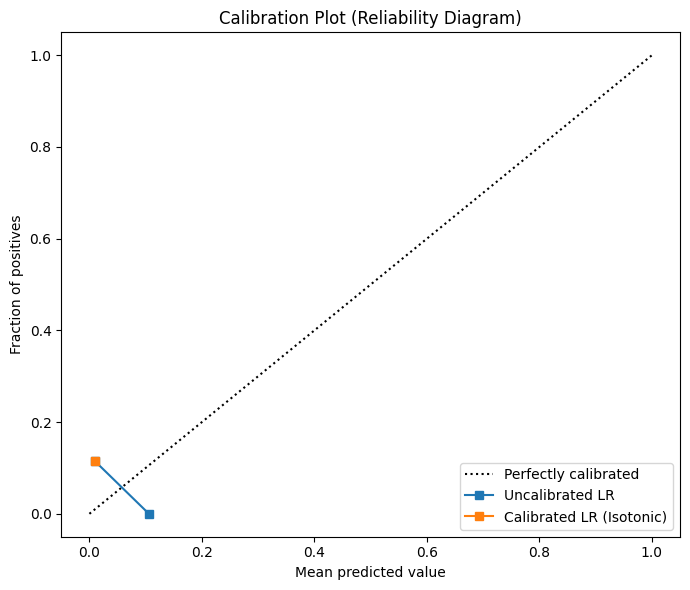

ROC-AUC (Uncalibrated LR): 0.4497
ROC-AUC (Calibrated LR): 0.4112


In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Let's use a base Logistic Regression model to demonstrate calibration
# Assume this model is not perfectly calibrated.
base_uncalibrated_lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
])

base_uncalibrated_lr.fit(X_train, y_train)
y_proba_uncalibrated = base_uncalibrated_lr.predict_proba(X_test)[:, 1]

# Calibrate the base model using Platt scaling (method='isotonic' is another option)
# CalibratedClassifierCV uses cross-validation internally for calibration.
calibrated_lr_pipe = CalibratedClassifierCV(
    base_uncalibrated_lr, method='isotonic', cv=5
)

# Note: CalibratedClassifierCV trains the base estimator multiple times
# for calibration, so it needs to be fit on X_train, y_train directly or
# the base_estimator should not be a full pipeline if it's already preprocessed.
# For simplicity, we pass the pipeline which will be cloned and fit internally.

calibrated_lr_pipe.fit(X_train, y_train)
y_proba_calibrated = calibrated_lr_pipe.predict_proba(X_test)[:, 1]

# Plot reliability diagrams to visualize calibration
fraction_of_positives_uncalibrated, mean_predicted_value_uncalibrated = calibration_curve(
    y_test, y_proba_uncalibrated, n_bins=10
)
fraction_of_positives_calibrated, mean_predicted_value_calibrated = calibration_curve(
    y_test, y_proba_calibrated, n_bins=10
)

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.plot(mean_predicted_value_uncalibrated, fraction_of_positives_uncalibrated,
         "s-", label="Uncalibrated LR")
plt.plot(mean_predicted_value_calibrated, fraction_of_positives_calibrated,
         "s-", label="Calibrated LR (Isotonic)")
plt.ylabel("Fraction of positives")
plt.xlabel("Mean predicted value")
plt.title('Calibration Plot (Reliability Diagram)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC (Uncalibrated LR): {roc_auc_score(y_test, y_proba_uncalibrated):.4f}")
print(f"ROC-AUC (Calibrated LR): {roc_auc_score(y_test, y_proba_calibrated):.4f}")


## 17.6 Online Learning / Incremental Learning

**WHY:** Traditional machine learning models are typically trained once on a fixed dataset (batch learning). However, in scenarios with continuous data streams (e.g., real-time sensor data, financial transactions) or datasets too large to fit into memory, online learning (or incremental learning) becomes essential. These models update their parameters incrementally as new data arrives, without needing to retrain on the entire historical dataset, making them efficient for dynamic environments and big data.

Training SGDClassifier incrementally over 46 batches...

Incremental training complete.
Final accuracy of online SGDClassifier on full dataset: 0.8613


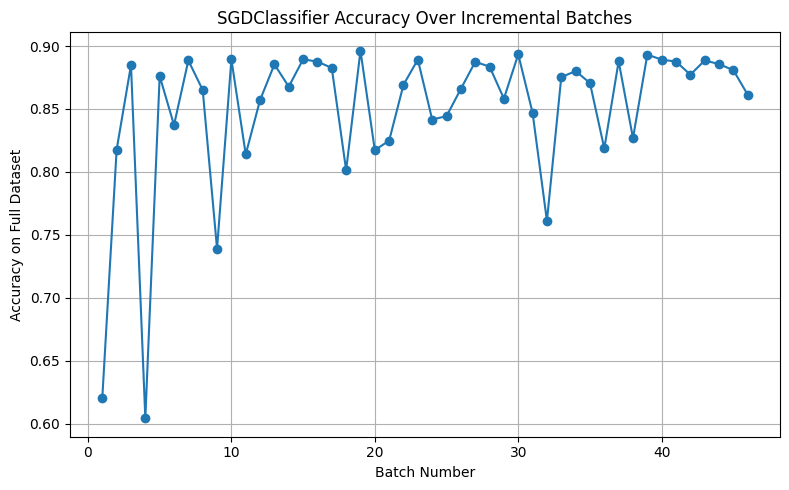

Accuracy of batch-trained SGDClassifier on full dataset: 0.9022


In [ ]:
from sklearn.linear_model import SGDClassifier
import numpy as np

# For online learning, models need to support `partial_fit`.
# SGDClassifier is a good example.

# Preprocess the entire X dataset first for consistent feature space
X_preprocessed = preprocessor.fit_transform(X)

# Ensure y is encoded if not already (for SGDClassifier classes_ argument)
if y.dtype == object:
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
else:
    y_encoded = y.values # Ensure it's a numpy array

# Define the online learner
online_sgd = SGDClassifier(loss='log_loss', random_state=RANDOM_STATE, warm_start=True)

# Define the classes present in the target variable
classes = np.unique(y_encoded)

# Simulate streaming data by training in batches
batch_size = 100
num_batches = int(np.ceil(len(X_preprocessed) / batch_size))

print(f"Training SGDClassifier incrementally over {num_batches} batches...")

# Store accuracy over batches
batch_accuracies = []

for i in range(num_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, len(X_preprocessed))

    X_batch = X_preprocessed[start_idx:end_idx]
    y_batch = y_encoded[start_idx:end_idx]

    if len(y_batch) > 0:
        online_sgd.partial_fit(X_batch, y_batch, classes=classes)

        # Evaluate on the full preprocessed dataset after each batch (for demonstration)
        # In a real online scenario, you'd evaluate on a separate validation stream.
        current_accuracy = online_sgd.score(X_preprocessed, y_encoded)
        batch_accuracies.append(current_accuracy)

print("\nIncremental training complete.")
final_online_accuracy = online_sgd.score(X_preprocessed, y_encoded)
print(f"Final accuracy of online SGDClassifier on full dataset: {final_online_accuracy:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_batches + 1), batch_accuracies, marker='o', linestyle='-')
plt.xlabel('Batch Number')
plt.ylabel('Accuracy on Full Dataset')
plt.title('SGDClassifier Accuracy Over Incremental Batches')
plt.grid(True)
plt.tight_layout()
plt.show()

# Compare with a batch-trained SGDClassifier
batch_sgd = SGDClassifier(loss='log_loss', random_state=RANDOM_STATE)
batch_sgd.fit(X_preprocessed, y_encoded)
batch_accuracy = batch_sgd.score(X_preprocessed, y_encoded)
print(f"Accuracy of batch-trained SGDClassifier on full dataset: {batch_accuracy:.4f}")


## 17.7 Feature Engineering

**WHY:** The raw features in a dataset might not always be in the most suitable form for a machine learning model to learn effective patterns. Feature engineering involves creating new features or transforming existing ones to make them more expressive and informative for the model. This often requires domain knowledge but can also involve general techniques such as:

*   **Polynomial Features:** Creating new features by raising existing features to a power (e.g., $x^2$, $x^3$). This allows linear models to capture non-linear relationships.
*   **Interaction Features:** Combining two or more features to capture their multiplicative interaction (e.g., $x_1 * x_2$). This can reveal relationships that individual features might miss.
*   **Custom Features:** Deriving features based on domain understanding or common patterns (e.g., converting 'month' names to numerical order, creating 'total contacts' from campaign, pdays, previous).

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression # Added for robustness
from sklearn.metrics import accuracy_score, precision_score, recall_score # Added for robustness

# --- Safeguard: Re-initialize core variables if not defined (e.g., after kernel restart) ---
if 'X_train' not in locals():
    print("\n--- Re-initializing core data variables for Feature Engineering ---")
    # Re-load data
    df = pd.read_csv("/content/bank.csv", sep=';') # Corrected file path from bank-full.csv to bank.csv
    TARGET_COL = "y"
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL]
    if y.dtype == object:
        y = pd.Series(LabelEncoder().fit_transform(y), name="target")

    # Re-split data
    RANDOM_STATE = 42
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )

    # Re-define numeric/categorical columns
    numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

    # Re-define preprocessor
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ])
    preprocessor.fit(X_train) # Fit the preprocessor for immediate use

    # Re-define make_pipeline (assuming USE_SMOTE is consistent)
    HAS_IMBLEARN = True # Assume imblearn is installed, as per initial setup
    imbalance_ratio = y_train.value_counts(normalize=True).min()
    USE_SMOTE = HAS_IMBLEARN and imbalance_ratio < 0.35

    def make_pipeline(model):
        """Builds preprocessing (+ optional SMOTE) + model as one leakage-safe unit."""
        if USE_SMOTE:
            return ImbPipeline(steps=[
                ("preprocess", preprocessor),
                ("smote", SMOTE(random_state=RANDOM_STATE)),
                ("model", model),
            ])
        return Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ])
    print("--- Core data variables re-initialized successfully ---")


# Let's apply feature engineering on the original X_train data before preprocessing
# This ensures that our preprocessor (imputation, scaling, one-hot encoding)
# handles these new features correctly.

# --- 1. Custom Feature Engineering (based on domain knowledge) ---
# The 'month' column is categorical but has a natural order. Let's convert it to numeric.
month_mapping = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
    'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe['month_num'] = X_train_fe['month'].map(month_mapping)
X_test_fe['month_num'] = X_test_fe['month'].map(month_mapping)

# Create a 'total_past_contacts' feature from 'campaign', 'pdays', 'previous'
# Note: 'pdays' == -1 often means the client was not previously contacted.
# We'll treat -1 in pdays as 0 for sum for this custom feature, assuming 0 implies no prior interaction context.

X_train_fe['total_past_contacts'] = X_train_fe['campaign'] + X_train_fe['previous'] + (X_train_fe['pdays'].apply(lambda x: 0 if x == -1 else 1))
X_test_fe['total_past_contacts'] = X_test_fe['campaign'] + X_test_fe['previous'] + (X_test_fe['pdays'].apply(lambda x: 0 if x == -1 else 1))

print("Original features (X_train_fe head):\n", X_train_fe[['campaign', 'pdays', 'previous', 'month']].head())
print("New features (X_train_fe head):\n", X_train_fe[['total_past_contacts', 'month_num']].head())

# Update numeric and categorical columns to reflect new/modified features for the preprocessor
# 'month' is now effectively replaced by 'month_num' for numerical processing,
# but we keep 'month' in categorical for now in case onehot encoder would handle it better.

numeric_cols_fe = numeric_cols + ['month_num', 'total_past_contacts']
categorical_cols_fe = [col for col in categorical_cols if col != 'month'] + ['month'] # Keep original month for demonstration if needed

# --- 2. Polynomial and Interaction Features ---
# We'll apply this on a subset of numerical features to avoid creating too many columns.
# It's usually done *after* basic numerical preprocessing (imputation, scaling).

# Define a temporary preprocessor for demonstration purposes that includes feature engineering
# In a real pipeline, these would be integrated into the main ColumnTransformer or as a separate pipeline step.

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

# Apply preprocessing up to scaling
X_train_processed_numeric_fe = preprocessor.named_transformers_['num'].fit_transform(X_train_fe[numeric_cols_fe])

# Generate polynomial and interaction features from a selection of processed numeric features
X_train_poly = poly.fit_transform(X_train_processed_numeric_fe[:, :5]) # Using first 5 numeric features for poly

print(f"\nShape after polynomial features: {X_train_poly.shape}")
print(f"Number of new features created by PolynomialFeatures: {X_train_poly.shape[1] - X_train_processed_numeric_fe[:, :5].shape[1]}")

# Example of how you would integrate this into a pipeline:
# (This is illustrative; actual implementation would integrate PolyFeatures directly into `numeric_transformer`)
# updated_numeric_transformer = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler()),
#     ("poly", PolynomialFeatures(degree=2, include_bias=False))
# ])

# For this demonstration, we'll retrain a simple Logistic Regression model
# with the custom engineered features added to the dataset and re-run preprocessing.

# Temporarily update the preprocessor to include the new custom features
# This is for demonstration. A robust solution would build a new preprocessor from X_train_fe.

# Re-create numeric_transformer using the updated list of numeric columns
updated_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

# Re-create categorical_transformer using the updated list of categorical columns
updated_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Re-create preprocessor with updated feature lists
preprocessor_fe = ColumnTransformer(transformers=[
    ("num", updated_numeric_transformer, numeric_cols_fe),
    ("cat", updated_categorical_transformer, categorical_cols_fe),
])

# Make a new make_pipeline function that uses preprocessor_fe
def make_pipeline_fe(model):
    """Builds preprocessing (with FE) (+ optional SMOTE) + model as one leakage-safe unit."""
    if USE_SMOTE:
        return ImbPipeline(steps=[
            ("preprocess", preprocessor_fe),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", model),
        ])
    return Pipeline(steps=[
        ("preprocess", preprocessor_fe),
        ("model", model),
    ])

print("\n--- Retraining Logistic Regression with Engineered Features ---")
lr_fe_pipe = make_pipeline_fe(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
lr_fe_pipe.fit(X_train_fe, y_train)
y_pred_fe = lr_fe_pipe.predict(X_test_fe)

print(f"Test Accuracy with Engineered Features: {accuracy_score(y_test, y_pred_fe):.4f}")
print(f"Precision with Engineered Features: {precision_score(y_test, y_pred_fe, average='weighted', zero_division=0):.4f}")
print(f"Recall with Engineered Features: {recall_score(y_test, y_pred_fe, average='weighted', zero_division=0):.4f}")

Original features (X_train_fe head):
       campaign  pdays  previous month
2236         3     -1         0   may
858          1     85        19   oct
3531         2     -1         0   aug
2737         1     -1         0   nov
1257         7     -1         0   jun
New features (X_train_fe head):
       total_past_contacts  month_num
2236                    3          5
858                    21         10
3531                    2          8
2737                    1         11
1257                    7          6

Shape after polynomial features: (3616, 20)
Number of new features created by PolynomialFeatures: 15

--- Retraining Logistic Regression with Engineered Features ---
Test Accuracy with Engineered Features: 0.8232
Precision with Engineered Features: 0.8981
Recall with Engineered Features: 0.8232
